<a href="https://colab.research.google.com/github/MinaAlberDS/Codveda-Internship/blob/master/Level%202/Task%203/K_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-mean clustering, PCA

## Prepare the notebook, and load the data

In [308]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sys
sys.path.append("/content/drive/MyDrive/Data Science/Colab Notebooks/Codveda/Level 2")
from Level_2.utils import *


## Load the data
df = pd.read_csv("/content/drive/MyDrive/Data Science/Colab Notebooks/Codveda/Level 2/Task 1/models_data.csv")
# Drop the log(price), because we don't need it
df.drop(["log(price)", "Is log(price) outlier"], axis = 1, inplace=True)
df

,name,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,...,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier
0,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,0,0,0,0,0,4.531093,11.170578,False,False
1,Beachfront Tower - B1,0,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,5.986452,12.020288,False,False
2,PODIA,0,1,1,0,1,1,0,0,0,...,0,1,0,1,0,0,4.532599,11.834229,False,False
3,Mazarine Apartment,1,1,0,0,0,0,1,0,1,...,0,0,0,0,0,0,5.529429,10.839970,False,False
4,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,5.344342,10.636903,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,5.178802,10.373308,False,False
852,Jade Park,1,0,1,1,0,0,1,0,1,...,0,0,0,0,0,0,6.539586,10.506413,False,True
853,Mamsha Avenue,1,1,0,0,1,0,1,0,1,...,0,0,0,0,0,0,5.141664,10.488183,False,False
854,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,0,0,0,0,0,5.335517,10.260524,False,False


## Handle the non-outliers

In [309]:
outliers_list = ["Is log(sqm) outlier", "Is log(price/sqm) outlier"] # the bool columns

non_outliers_mask = (1 - df[outliers_list].sum(axis = 1)).astype(bool) # the non-outliers mask
drop_cols = outliers_list + ["name"] # Not needed columns
non_outliers_df = df[non_outliers_mask].drop(drop_cols, axis = 1) # the non-outliers data

non_outliers_df # preview the data

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_New Cairo,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price/sqm)
0,1,1,0,0,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,4.531093,11.170578
1,0,0,0,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,5.986452,12.020288
2,0,1,1,0,1,1,0,0,0,1,...,0,0,0,1,0,1,0,0,4.532599,11.834229
3,1,1,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,5.529429,10.839970
4,1,1,0,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,5.344342,10.636903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849,1,1,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,4.867534,9.929402
850,1,1,0,0,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,4.835567,10.895689
851,1,1,0,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,5.178802,10.373308
853,1,1,0,0,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,5.141664,10.488183


In [310]:
### Standardize the continuous values
scaler = StandardScaler()
non_outliers_df[["log(sqm)", "log(price/sqm)"]] = scaler.fit_transform(non_outliers_df[["log(sqm)", "log(price/sqm)"]])
non_outliers_df

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_New Cairo,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price/sqm)
0,1,1,0,0,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,-1.528423,0.669119
1,0,0,0,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,1.626838,2.199718
2,0,1,1,0,1,1,0,0,0,1,...,0,0,0,1,0,1,0,0,-1.525157,1.864568
3,1,1,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0.635999,0.073589
4,1,1,0,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0.234724,-0.292200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849,1,1,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,-0.799008,-1.566634
850,1,1,0,0,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,-0.868314,0.173956
851,1,1,0,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,-0.124172,-0.767018
853,1,1,0,0,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,-0.204688,-0.560091


### Pick the clusters number using elbow method

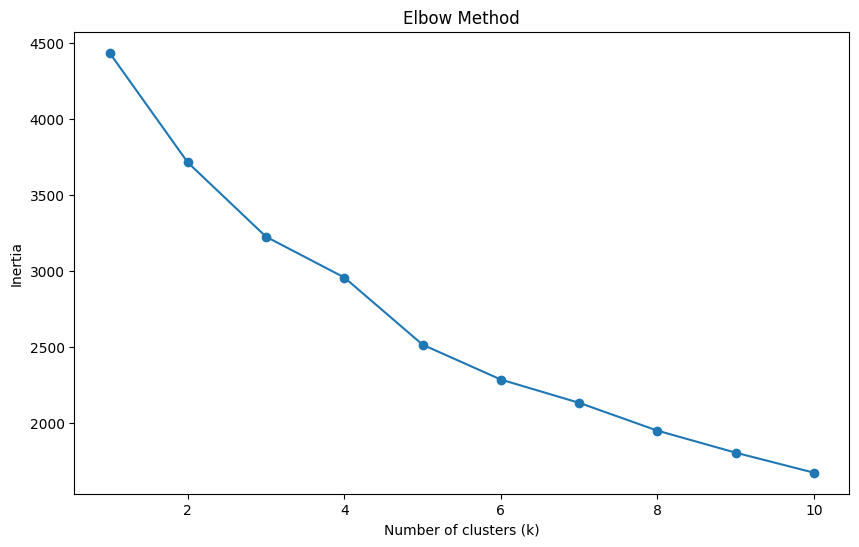

In [311]:
def elbow_method(df, k_range):
  """
  This function uses the elbow method to pick the number of clusters.
  Args:
    df: the dataframe to cluster
    k_range: the range of k values to test
  """
  inertia = []

  for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42) # Make the kmeans method using k cluster
    kmeans.fit(df) # fit the model
    inertia.append(kmeans.inertia_) # append the model intertia
  # plot the elbow chart
  plt.figure(figsize=(10, 6))
  plt.plot(k_range, inertia, marker='o')
  plt.xlabel('Number of clusters (k)')
  plt.ylabel('Inertia')
  plt.title('Elbow Method')
  plt.show()

elbow_method(non_outliers_df, range(1, 11))


- I will pick 4 clusters

### K-mean clustering

In [312]:
optimal_k = 4 # optimal clusters number based on the elbow chart
kmeans = KMeans(n_clusters=optimal_k, random_state=42) # Make the kmeans method using k cluster
non_outliers_df["Cluster"] = kmeans.fit_predict(non_outliers_df) # fit the model

non_outliers_df.head()

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price/sqm),Cluster
0,1,1,0,0,1,0,1,1,1,0,...,1,0,0,0,0,0,0,-1.528423,0.669119,2
1,0,0,0,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,1.626838,2.199718,1
2,0,1,1,0,1,1,0,0,0,1,...,0,0,1,0,1,0,0,-1.525157,1.864568,0
3,1,1,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0.635999,0.073589,1
4,1,1,0,0,1,0,0,0,0,1,...,1,0,0,0,0,0,0,0.234724,-0.292200,3


### PCA

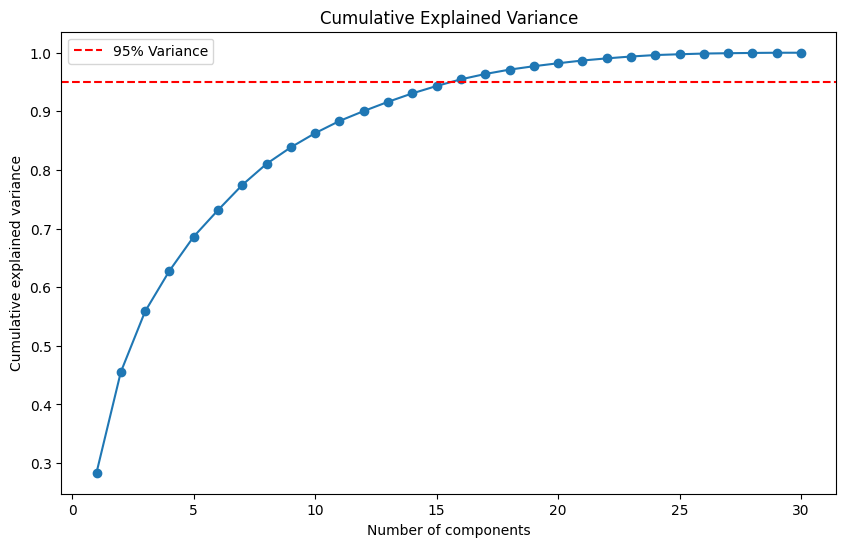

In [313]:
pca = PCA()

pca_features = pca.fit_transform(non_outliers_df.drop("Cluster", axis = 1)) # fit the model
explained_variance = np.cumsum(pca.explained_variance_ratio_)

def explained_variance_chart(explained_variance):
  """
  This function plots the explained variance chart
  Args:
    explained_variance: the explained variance
  """
  plt.figure(figsize=(10, 6)) # the figure size
  plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o') # plot the elbow chart
  plt.axhline(y=0.95, color='r', linestyle='--', label="95% Variance") # The 95% explained variance
  plt.xlabel('Number of components')
  plt.ylabel('Cumulative explained variance')
  plt.title('Cumulative Explained Variance')
  plt.legend()
  plt.show()

explained_variance_chart(explained_variance)


PCA 2d explaines approximately 50% of our variance

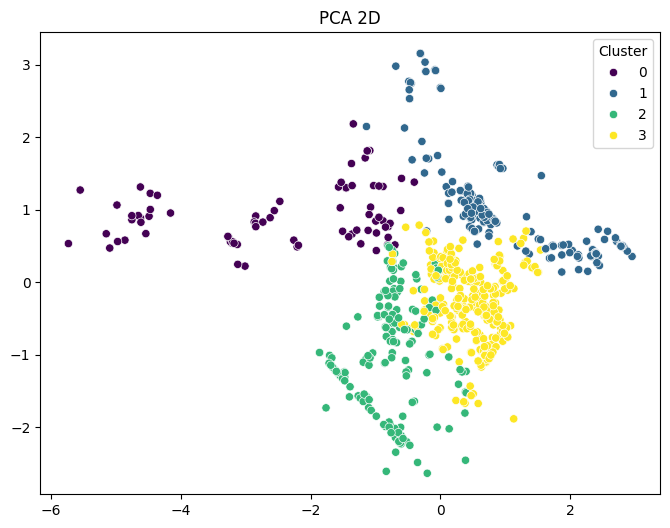

In [314]:
# plot the 2d PCA
pca_2d = pca_features[:,:2]

def pca_chart(pca_2d, clusters):
  """
  This function plots the 2d PCA
  Args:
    pca_2d: the 2d PCA
    clusters: the clusters
  """
  plt.figure(figsize=(8,6))
  sns.scatterplot(x= pca_2d[:,0], y= pca_2d[:,1], hue=clusters, palette="viridis")
  plt.title("PCA 2D")
  plt.show()

pca_chart(pca_2d, non_outliers_df["Cluster"])

### Clustering anaylsis

In [315]:
def clustering_analysis(df):
  """
  This function performs the clustering analysis
  Args:
    df: the dataframe to cluster
  """
  # Pick the columns
  numerical_columns = ["log(sqm)", "log(price/sqm)"]
  categorical_columns = [col for col in df.columns if col not in numerical_columns and col != "Cluster"]

  # Analysis
  ## Numerical analysis
  numerical_analysis = df.groupby("Cluster", as_index = False)[numerical_columns].agg(["mean","median", "max","min"])

  # Perform manual inverse transform for each numerical column
  for i, col in enumerate(numerical_columns):
      mean = scaler.mean_[i]
      scale = scaler.scale_[i]
      for stat in ["mean", "median", "max", "min"]:
          numerical_analysis[(col, stat)] = np.exp(numerical_analysis[(col, stat)].apply(lambda x: x * scale + mean))

  numerical_analysis.rename(columns = {"log(sqm)": "sqm", "log(price/sqm)": "price/sqm"}, inplace = True)

  # categorical analysis
  categorical_analysis = df.groupby("Cluster", as_index = False)[categorical_columns].agg(["mean","sum"])
  categorical_analysis.rename(columns={"mean": "proportion"}, level=1, inplace=True) # Rename 'mean' to 'proportion'

  # Combine them
  clusters_analysis = pd.merge(numerical_analysis, categorical_analysis, on = "Cluster")
  return clusters_analysis
non_outliers_analysis = clustering_analysis(non_outliers_df)
non_outliers_analysis

/tmp/ipython-input-1492965322.py:29: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  clusters_analysis = pd.merge(numerical_analysis, categorical_analysis, on = "Cluster")


Cluster         sqm                                 price/sqm  \
                 mean      median    max     min           mean   
0       0  113.023162  124.000000  338.0   27.00  153756.544312   
1       1  301.275980  261.264772  504.0  206.32   51274.405013   
2       2  122.831478  126.000000  224.0   66.88   47162.524881   
3       3  204.687139  207.000000  392.0  110.00   37738.934911   

                                          has_main_facilities  ...  \
          median          max         min          proportion  ...   
0  136930.555600  518794.8718  61929.3478            0.467532  ...   
1   52450.162222  176316.6144  20198.4127            0.730769  ...   
2   49040.462400  108589.2857  15025.2982            0.798883  ...   
3   36474.611521  111873.6462  14620.3202            0.813953  ...   

  propertyCategory_Commercial     propertySubType_Attached Houses      \
                   proportion sum                      proportion sum   
0                    0.935065  72                        0.012987   1   
1                    0.000000   0                        0.296703  54   
2                    0.005587   1                        0.022346   4   
3                    0.005814   2                        0.002907   1   

  propertySubType_Office     propertySubType_Others(very rare)      \
              proportion sum                        proportion sum   
0               0.389610  30                          0.012987   1   
1               0.000000   0                          0.005495   1   
2               0.005587   1                          0.000000   0   
3               0.005814   2                          0.000000   0   

  propertySubType_Retail      
              proportion sum  
0               0.532468  41  
1               0.000000   0  
2               0.000000   0  
3               0.000000   0  

[4 rows x 65 columns]

- I will summarize the final data after the outliers clusters

## outliers clusters

### Prepare the data

In [316]:
df.head()

,name,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,...,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier
0,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,0,0,0,0,0,4.531093,11.170578,False,False
1,Beachfront Tower - B1,0,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,5.986452,12.020288,False,False
2,PODIA,0,1,1,0,1,1,0,0,0,...,0,1,0,1,0,0,4.532599,11.834229,False,False
3,Mazarine Apartment,1,1,0,0,0,0,1,0,1,...,0,0,0,0,0,0,5.529429,10.839970,False,False
4,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,5.344342,10.636903,False,False


In [317]:
outliers_mask = (1 - non_outliers_mask).astype(bool)

outliers_df = df[outliers_mask].drop(drop_cols, axis = 1)
outliers_df

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_New Cairo,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price/sqm)
17,1,1,0,1,0,0,1,0,1,0,...,1,0,0,1,0,1,0,0,5.201090,12.150323
23,1,1,0,1,0,0,0,0,1,0,...,1,0,0,1,0,1,0,0,5.173434,12.226595
24,0,1,1,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,1,4.166665,12.357295
28,1,1,0,1,0,0,1,0,1,0,...,1,0,0,1,0,1,0,0,5.153118,12.259732
31,1,1,0,1,0,0,1,0,1,0,...,1,0,0,1,0,1,0,0,5.356067,12.231399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0,1,0,0,1,1,0,1,0,1,...,1,0,0,0,0,0,0,0,3.113515,11.202164
844,1,1,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,6.414933,10.278089
846,0,1,0,0,1,1,0,1,0,1,...,1,0,0,0,0,0,0,0,2.708050,11.296426
852,1,0,1,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,6.539586,10.506413


### Standardizing

In [318]:
outliers_df[["log(sqm)","log(price/sqm)"]] = scaler.fit_transform(outliers_df[["log(sqm)","log(price/sqm)"]])

outliers_df

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_New Cairo,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price/sqm)
17,1,1,0,1,0,0,1,0,1,0,...,1,0,0,1,0,1,0,0,-0.102559,0.356347
23,1,1,0,1,0,0,0,0,1,0,...,1,0,0,1,0,1,0,0,-0.135128,0.454104
24,0,1,1,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,1,-1.320763,0.621622
28,1,1,0,1,0,0,1,0,1,0,...,1,0,0,1,0,1,0,0,-0.159054,0.496575
31,1,1,0,1,0,0,1,0,1,0,...,1,0,0,1,0,1,0,0,0.079952,0.460262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0,1,0,0,1,1,0,1,0,1,...,1,0,0,0,0,0,0,0,-2.561020,-0.858901
844,1,1,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1.326940,-2.043281
846,0,1,0,0,1,1,0,1,0,1,...,1,0,0,0,0,0,0,0,-3.038521,-0.738086
852,1,0,1,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,1.473739,-1.750640


### Elbow method

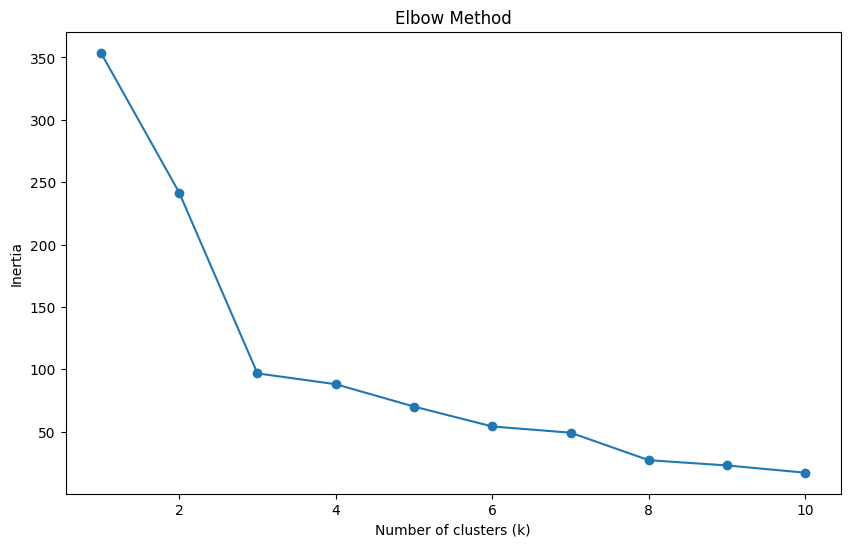

In [319]:
elbow_method(outliers_df, range(1, 11))

I will pick three clusters

### K-mean Clustering

In [320]:
optimal_k = 3 # optimal clusters number based on the elbow chart
kmeans = KMeans(n_clusters=optimal_k, random_state=42) # Make the kmeans method using k cluster
outliers_df["Cluster"] = -1 - kmeans.fit_predict(outliers_df)# fit the model, and add labels -1, -2, -3 to distinguish it
outliers_df

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price/sqm),Cluster
17,1,1,0,1,0,0,1,0,1,0,...,0,0,1,0,1,0,0,-0.102559,0.356347,-2
23,1,1,0,1,0,0,0,0,1,0,...,0,0,1,0,1,0,0,-0.135128,0.454104,-2
24,0,1,1,0,1,0,0,0,0,1,...,0,0,1,0,0,0,1,-1.320763,0.621622,-1
28,1,1,0,1,0,0,1,0,1,0,...,0,0,1,0,1,0,0,-0.159054,0.496575,-2
31,1,1,0,1,0,0,1,0,1,0,...,0,0,1,0,1,0,0,0.079952,0.460262,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0,1,0,0,1,1,0,1,0,1,...,0,0,0,0,0,0,0,-2.561020,-0.858901,-1
844,1,1,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1.326940,-2.043281,-3
846,0,1,0,0,1,1,0,1,0,1,...,0,0,0,0,0,0,0,-3.038521,-0.738086,-1
852,1,0,1,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,1.473739,-1.750640,-3


### PCA

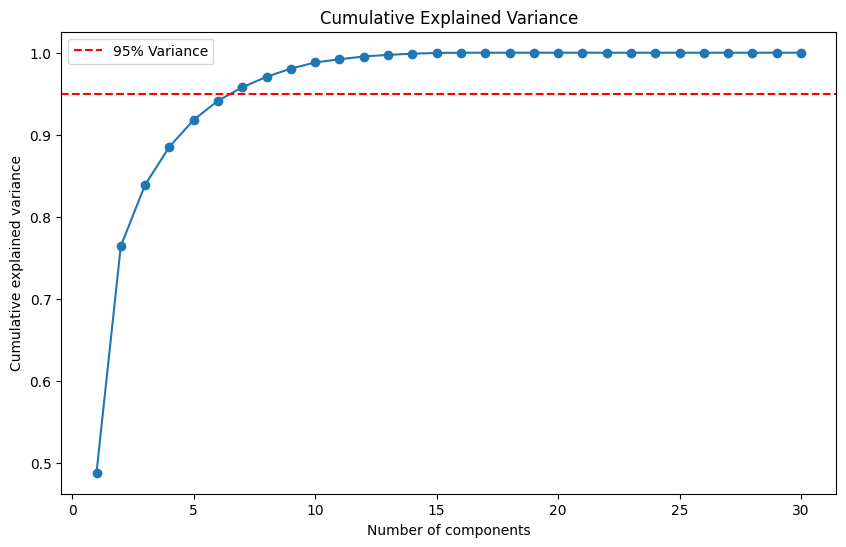

In [321]:
pca = PCA()

pca_features = pca.fit_transform(outliers_df.drop("Cluster", axis = 1)) # fit the model
explained_variance = np.cumsum(pca.explained_variance_ratio_)

explained_variance_chart(explained_variance)

- PCA 2d explain apprometally 80%

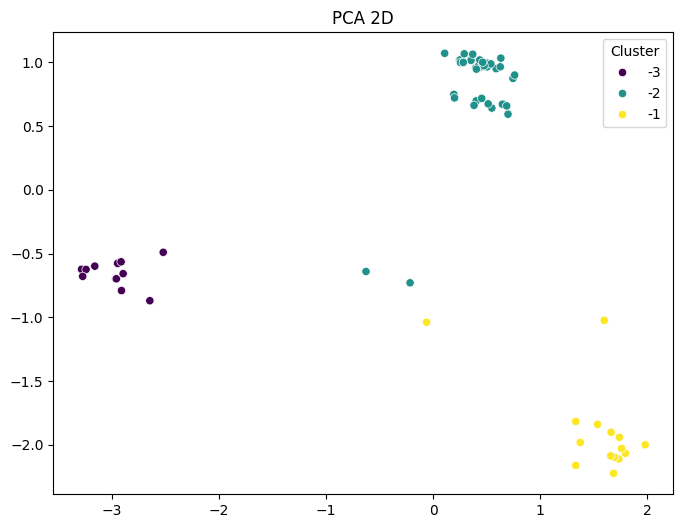

In [322]:
outliers_pca_2d = pca_features[:,:2]

pca_chart(outliers_pca_2d, outliers_df["Cluster"])

### Clustering analysis

In [323]:
outliers_analysis = clustering_analysis(outliers_df)
outliers_analysis

/tmp/ipython-input-1492965322.py:29: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  clusters_analysis = pd.merge(numerical_analysis, categorical_analysis, on = "Cluster")


Cluster         sqm                             price/sqm                 \
                 mean  median    max     min           mean         median   
0      -3  742.513400  740.00  990.0  598.10   30823.462492   31450.346671   
1      -2  186.703070  176.52  724.0  112.49  203284.600546  200421.609300   
2      -1   68.745391   68.50  319.0   15.00  210225.846643  232656.934300   

                            has_main_facilities  ...  \
           max          min          proportion  ...   
0   36600.0000   23914.9541                 1.0  ...   
1  250152.9572  167296.9613                 1.0  ...   
2  343147.1698   73288.8889                 0.0  ...   

  propertyCategory_Commercial     propertySubType_Attached Houses      \
                   proportion sum                      proportion sum   
0                         0.0   0                             0.0   0   
1                         1.0  45                             0.0   0   
2                         0.8  12                             0.0   0   

  propertySubType_Office     propertySubType_Others(very rare)      \
              proportion sum                        proportion sum   
0               0.000000   0                          0.785714  11   
1               0.955556  43                          0.000000   0   
2               0.066667   1                          0.066667   1   

  propertySubType_Retail      
              proportion sum  
0               0.000000   0  
1               0.044444   2  
2               0.666667  10  

[3 rows x 65 columns]

## Summarizing the results

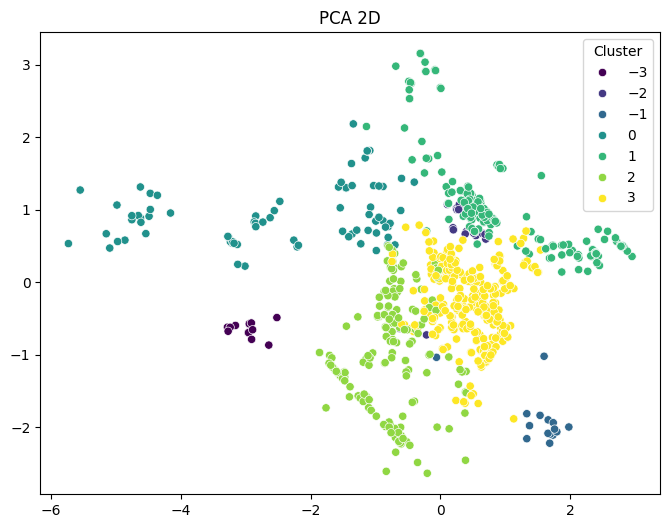

In [329]:
# Merge both outliers, and non-outliers in one dataframe to plot them
final_df = pd.concat([outliers_df, non_outliers_df])
final_df.reset_index(drop = True, inplace = True)

# plot the final PCA 2d

final_pca_2d = np.concat([outliers_pca_2d[:,:2], pca_2d], axis = 0)

pca_chart(final_pca_2d, final_df["Cluster"])

In [330]:
# Merge the two analysis in one analysis, then summarize it using LLM

final_analysis = pd.concat([outliers_analysis, non_outliers_analysis])
final_analysis.reset_index(drop = True, inplace = True)
final_analysis

Cluster         sqm                                 price/sqm  \
                 mean      median    max     min           mean   
0      -3  742.513400  740.000000  990.0  598.10   30823.462492   
1      -2  186.703070  176.520000  724.0  112.49  203284.600546   
2      -1   68.745391   68.500000  319.0   15.00  210225.846643   
3       0  113.023162  124.000000  338.0   27.00  153756.544312   
4       1  301.275980  261.264772  504.0  206.32   51274.405013   
5       2  122.831478  126.000000  224.0   66.88   47162.524881   
6       3  204.687139  207.000000  392.0  110.00   37738.934911   

                                           has_main_facilities  ...  \
          median          max          min          proportion  ...   
0   31450.346671   36600.0000   23914.9541            1.000000  ...   
1  200421.609300  250152.9572  167296.9613            1.000000  ...   
2  232656.934300  343147.1698   73288.8889            0.000000  ...   
3  136930.555600  518794.8718   61929.3478            0.467532  ...   
4   52450.162222  176316.6144   20198.4127            0.730769  ...   
5   49040.462400  108589.2857   15025.2982            0.798883  ...   
6   36474.611521  111873.6462   14620.3202            0.813953  ...   

  propertyCategory_Commercial     propertySubType_Attached Houses      \
                   proportion sum                      proportion sum   
0                    0.000000   0                        0.000000   0   
1                    1.000000  45                        0.000000   0   
2                    0.800000  12                        0.000000   0   
3                    0.935065  72                        0.012987   1   
4                    0.000000   0                        0.296703  54   
5                    0.005587   1                        0.022346   4   
6                    0.005814   2                        0.002907   1   

  propertySubType_Office     propertySubType_Others(very rare)      \
              proportion sum                        proportion sum   
0               0.000000   0                          0.785714  11   
1               0.955556  43                          0.000000   0   
2               0.066667   1                          0.066667   1   
3               0.389610  30                          0.012987   1   
4               0.000000   0                          0.005495   1   
5               0.005587   1                          0.000000   0   
6               0.005814   2                          0.000000   0   

  propertySubType_Retail      
              proportion sum  
0               0.000000   0  
1               0.044444   2  
2               0.666667  10  
3               0.532468  41  
4               0.000000   0  
5               0.000000   0  
6               0.000000   0  

[7 rows x 65 columns]

### Summarize the results using LLM LLama

You'll need an API key from Groq. If you don't have one, you can create one [here](https://console.groq.com/keys). In Colab, you can add your API key to the secrets manager under the "🔑" in the left panel and name it `GROQ_API_KEY`.

In [326]:
from google.colab import userdata
from groq import Groq

client = Groq(
    api_key=userdata.get('GROQ_API_KEY'),
)

In [327]:
prompt = f"""
Using the following dataframe which contains the numerical and categorical analysis of different clusters, summarize the key characteristics of each cluster, and give a name for each cluster(7 clusters). Focus on the differences in 'sqm' (mean, median, max, min), 'price/sqm' (mean, median, max, min), and the proportions of the categorical features. Describe what makes each cluster distinct.

{final_analysis.to_markdown()}
"""

chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": prompt,
        }
    ],
    model="llama-3.1-8b-instant",
)

print(chat_completion.choices[0].message.content)

Based on the provided data, we can identify 7 distinct clusters and summarize their key characteristics. Let's assign names to each cluster based on their prominent features.

**Cluster 1: Luxury Mansoura Properties (Cluster -3)**

* Mean sqm: 742.51
* Median sqm: 740
* Max sqm: 990
* Min sqm: 598.1
* Mean price/sqm: 30,823.5
* Median price/sqm: 31,450.3
* Max price/sqm: 36,600
* Min price/sqm: 23,915
* Has main facilities: 71.43%
* Has security features: 14
* Has parking safety: 12
* Has modern features: 100%
* Has facilities: 100%

This cluster represents high-end properties in Mansoura, with large sqm sizes, high prices, and a high demand for luxury features.

**Cluster 2: Large Office Spaces in New Cairo (Cluster -2)**

* Mean sqm: 186.7
* Median sqm: 176.52
* Max sqm: 724
* Min sqm: 112.49
* Mean price/sqm: 203,285
* Median price/sqm: 200,422
* Max price/sqm: 250,153
* Min price/sqm: 167,297
* Has main facilities: 100%
* Has security features: 100%
* Has parking safety: 0%
* Has m

### Final step:
- Rename the clusters

In [331]:
new_names = ["Luxury Mansoura Properties","Large Office Spaces in New Cairo"," Mid-Sized Apartments in Old Cairo","Detached Houses in New Administrative Capital",
             "High-Demand Properties in North Coast","Large Detached Houses in Cairo","High-End Apartments in Mansoura"]
old_ones = ["-3","-2","-1","0","1","2","3"]

final_df["Cluster"] = final_df["Cluster"].astype(str)
final_df["Cluster"] = final_df["Cluster"].replace(old_ones, new_names)
final_df.head()

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price/sqm),Cluster
0,1,1,0,1,0,0,1,0,1,0,...,0,0,1,0,1,0,0,-0.102559,0.356347,Large Office Spaces in New Cairo
1,1,1,0,1,0,0,0,0,1,0,...,0,0,1,0,1,0,0,-0.135128,0.454104,Large Office Spaces in New Cairo
2,0,1,1,0,1,0,0,0,0,1,...,0,0,1,0,0,0,1,-1.320763,0.621622,Mid-Sized Apartments in Old Cairo
3,1,1,0,1,0,0,1,0,1,0,...,0,0,1,0,1,0,0,-0.159054,0.496575,Large Office Spaces in New Cairo
4,1,1,0,1,0,0,1,0,1,0,...,0,0,1,0,1,0,0,0.079952,0.460262,Large Office Spaces in New Cairo


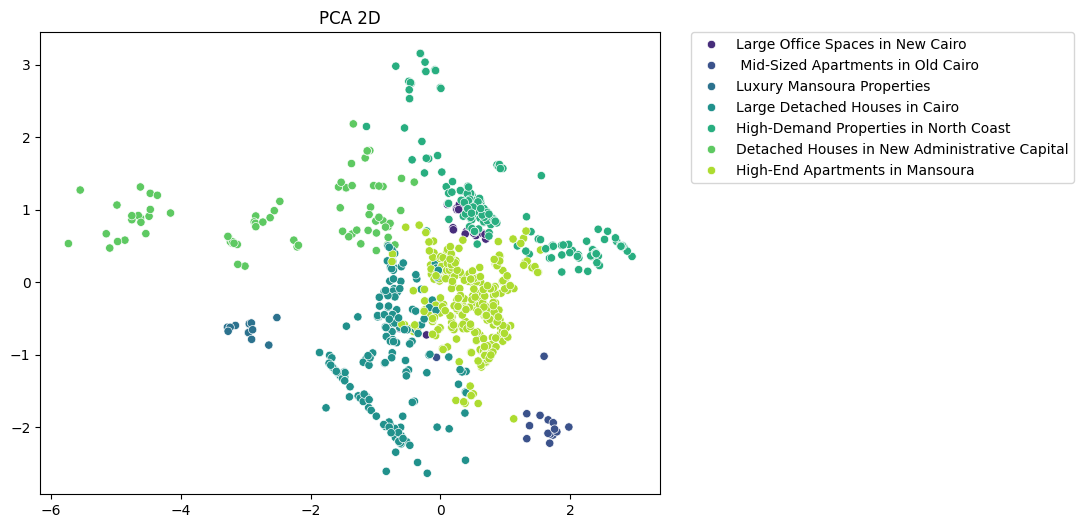

In [334]:
## Plot the final PCA 2D
plt.figure(figsize=(8,6))
ax = sns.scatterplot(x= final_pca_2d[:,0], y= final_pca_2d[:,1], hue=final_df["Cluster"], palette="viridis")
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA 2D")
plt.show()

# Notebook Summary

This notebook focuses on applying K-Means clustering and PCA to analyze property data.

The key steps performed are:
1.  **Data Loading and Preparation**: The property data was loaded, and irrelevant columns were dropped.
2.  **Outlier Handling**: Data points identified as outliers based on log-transformed 'sqm' and 'price/sqm' were separated from the non-outliers.
3.  **Standardization**: The numerical features ('log(sqm)' and 'log(price/sqm)') for both the non-outlier and outlier datasets were standardized using `StandardScaler`.
4.  **K-Means Clustering**: The Elbow method was used to determine the optimal number of clusters for both the non-outlier and outlier datasets. K-Means clustering was then applied with the chosen number of clusters.
5.  **PCA**: Principal Component Analysis (PCA) was performed on both the non-outlier and outlier datasets to reduce dimensionality and visualize the clusters in 2D.
6.  **Cluster Analysis**: A detailed analysis of the numerical and categorical features within each cluster was conducted. This involved calculating descriptive statistics for numerical features (mean, median, max, min) and proportions for categorical features. The inverse transform was manually applied to the numerical statistics to bring them back to the original scale.
7.  **Combining and Summarizing Results**: The outlier and non-outlier clusters were combined, and a language model (LLM) was used to generate a summary of the characteristics of each of the 7 clusters based on the analysis.
8.  **Visualization**: The final clusters were visualized using a 2D PCA plot with the clusters colored differently.
9.  **Cluster Renaming**: The clusters were renamed based on the characteristics identified by the LLM for better interpretation.